# Pipeline 10: Social Media Engagement -> Donation Impact

**Organization:** River of Life / Lighthouse Sanctuary (INTEX)  
**Methodology:** CRISP-DM–aligned (see `pipeline_guide.md` in this folder)

---

## Executive Summary

This pipeline focuses on **engagement signals that correlate with donations**, not vanity engagement alone. We model donation-linked outcomes and keep engagement as an explanatory mediator.

**What this notebook delivers**
- Primary target: donation_referrals and estimated donation value
- Baseline + interpretable + performance models
- Heavy use of `social_media_posts.csv` with deployment-ready scoring tables

### Pipeline strength tier
**Exploratory-operational:** platform algorithms change quickly; retrain frequently and validate with experiments.

*Non-technical readers:* skim the Executive Summary, **Business Interpretation**, **Key Findings**, and **Recommended Actions**, then use charts in Sections 3–5 for discussion with data staff.

---


## 1. Problem Framing

### Business problem
The team wants to know which post characteristics drive **donation outcomes**, not just likes/comments.

### Stakeholders
| **Digital comms** | Content choices |
| **Fundraising** | Campaign ROI |
| **Leadership** | Budget allocation |

### Why this matters
High engagement without donation lift can consume budget and attention with limited mission impact.

### Predictive goal (what we forecast or score)
Predict **donation_referrals** (count) and **estimated_donation_value_php** from post attributes, with a binary high-conversion flag for triage.

### Explanatory goal (what we want to understand)
Quantify which content/timing/platform factors align with stronger donation-linked outcomes, while showing engagement as a related mediator.

### Why predictive and explanatory are different
Predictive model optimizes ranking and expected value; interpretable model supports strategy conversations and creative guidelines.

### Decision this work supports
Which post types to prioritize in calendar, where to spend boost budget, and which posts enter rapid-response fundraising queue.

### Limitations (preview)
Correlational evidence only; boosted posts and platform algorithms confound causal interpretation.

---


## Data Validity & Leakage Check

### How the target is defined
Primary regression target: `estimated_donation_value_php`; secondary classification target: `high_conversion_post` where donation_referrals >= median positive referrals.

### What information is allowed at prediction time
Use pre-publish and early metadata fields (platform, post_type, topic, timing, CTA, caption features, boost flag/budget).

### Why future information does not leak into features
Do not use downstream donation fields as features; engagement metrics are used in explanatory EDA but excluded from strict pre-publish predictive feature set.

### Why the train/test approach is valid
KFold with shuffle is used for this post-level dataset; recommended production upgrade is time-based split by created_at month.

### Automated checks in this notebook
Notebook explicitly builds `feature_cols_strict` excluding post-outcome leakage columns.

---


## 2. Data Acquisition & Preparation

**Table:** `social_media_posts.csv` (primary source).

Preparation emphasizes donation-linked columns: `donation_referrals`, `estimated_donation_value_php`, plus post metadata and CTA fields.

---


In [4]:
import json
import warnings
from datetime import timedelta
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns  # noqa: F401 — used in EDA cells across generated notebooks

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk", font_scale=0.85)

def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "lighthouse_csv_v7").is_dir():
            return p
    raise FileNotFoundError(
        "Could not find lighthouse_csv_v7. Open or run from the INTEX II EDA project folder."
    )

PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "lighthouse_csv_v7"
OUTPUT_DIR = PROJECT_ROOT / "ml_pipelines" / "artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_ROOT:", PROJECT_ROOT.resolve())


PROJECT_ROOT: /Users/jaxon/Documents/BYU Archive/Winter 2026 - Junior Core IS/INTEX II/INTEX II EDA


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score, roc_auc_score, classification_report
from sklearn.model_selection import KFold, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

soc = pd.read_csv(DATA_DIR / "social_media_posts.csv", parse_dates=["created_at"])
# Keep rows with donation-linked targets
soc = soc.dropna(subset=["donation_referrals", "estimated_donation_value_php"]).copy()

# Coerce numeric fields used for modeling
num_candidates = [
    "post_hour", "caption_length", "num_hashtags", "mentions_count", "boost_budget_php",
    "follower_count_at_post", "subscriber_count_at_post", "watch_time_seconds", "avg_view_duration_seconds",
]
for col in num_candidates:
    if col in soc.columns:
        soc[col] = pd.to_numeric(soc[col], errors="coerce").fillna(0)

if "is_boosted" in soc.columns:
    soc["is_boosted"] = soc["is_boosted"].astype(str).str.lower().eq("true").astype(int)
if "has_call_to_action" in soc.columns:
    soc["has_call_to_action"] = soc["has_call_to_action"].astype(str).str.lower().eq("true").astype(int)

# Strict pre-publish-ish feature set (no downstream outcomes like impressions/likes/clicks/referrals/value)
feature_num = [c for c in ["post_hour", "caption_length", "num_hashtags", "mentions_count", "is_boosted", "boost_budget_php", "follower_count_at_post"] if c in soc.columns]
feature_cat = [c for c in ["platform", "post_type", "media_type", "content_topic", "sentiment_tone", "call_to_action_type", "campaign_name"] if c in soc.columns]

X = soc[feature_num + feature_cat].copy()
y_value = pd.to_numeric(soc["estimated_donation_value_php"], errors="coerce").fillna(0)
y_ref = pd.to_numeric(soc["donation_referrals"], errors="coerce").fillna(0)
pos_ref = y_ref[y_ref > 0]
ref_thresh = pos_ref.median() if len(pos_ref) else 1
y_high = (y_ref >= ref_thresh).astype(int)

prep = ColumnTransformer([
    ("num", StandardScaler(), feature_num),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), feature_cat),
])

def reg_pipe(m):
    return Pipeline([("prep", prep), ("model", m)])

def clf_pipe(m):
    return Pipeline([("prep", prep), ("model", m)])

print("Rows:", len(soc), "high-conversion rate:", y_high.mean(), "ref threshold:", ref_thresh)


Rows: 812 high-conversion rate: 0.3485221674876847 ref threshold: 6.0


## 3. Exploration (EDA)

We visualize distributions and relationships **relevant to the business question**, not generic plots. Narrative interpretation follows each chart in markdown where noted.

---


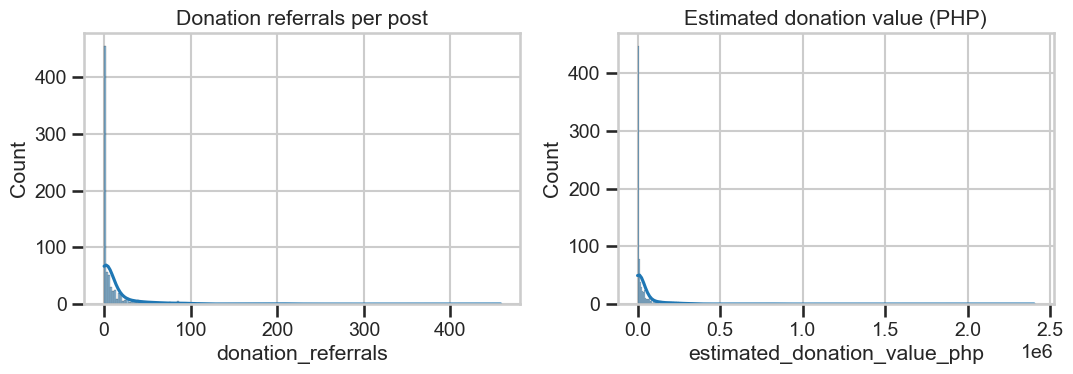

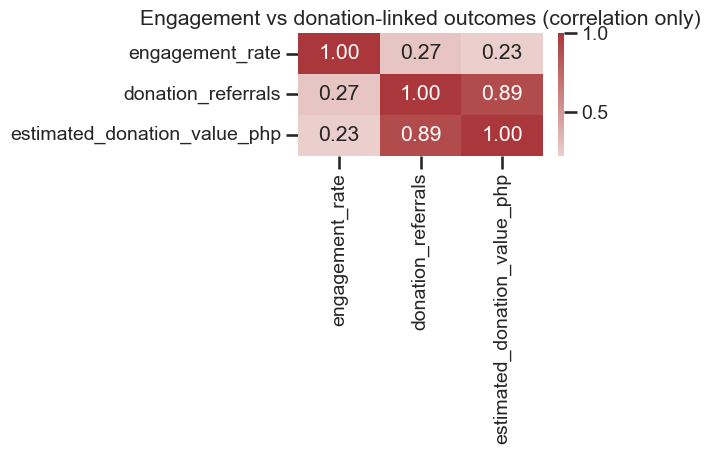

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(y_ref, kde=True, ax=ax[0])
ax[0].set_title("Donation referrals per post")
sns.histplot(y_value, kde=True, ax=ax[1])
ax[1].set_title("Estimated donation value (PHP)")
plt.tight_layout(); plt.show()

if "engagement_rate" in soc.columns:
    corr = pd.DataFrame({
        "engagement_rate": pd.to_numeric(soc["engagement_rate"], errors="coerce").fillna(0),
        "donation_referrals": y_ref,
        "estimated_donation_value_php": y_value,
    }).corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
    plt.title("Engagement vs donation-linked outcomes (correlation only)")
    plt.tight_layout(); plt.show()


## 4. Modeling & Feature Selection

### Feature rationale (why these inputs)
Use post metadata and campaign setup variables available before/at publish; reserve engagement metrics for explanatory analysis and diagnostics.

### Three-model strategy
1. **Baseline — Dummy mean regressor (value) and stratified dummy classifier (high-conversion flag):** trivial rule so we never mistake “model” for “signal.”
2. **Interpretable — Ridge regression (donation value) + Logistic regression (high conversion):** coefficients or clear structure for **explanation** and stakeholder trust.
3. **Performance — Random Forest regressor/classifier:** stronger fit for **batch scoring**; may sacrifice some interpretability.

### Feature selection
We keep the feature set **parsimonious** and justified; where helpful, regularization (Ridge / L1) or tree-based implicit selection reduces noise. Final model choice is documented in Section 5 with **tradeoffs**.

---


VALUE baseline MAE 52771.01260095879 R2 -0.004188906325542208
VALUE ridge MAE 53600.80548447252 R2 0.07113303493402685
VALUE rf MAE 40824.891537490614 R2 0.08916972065370507
HIGH_CONV baseline AUC 0.47832551227942377 F1 0.30314478002809686
HIGH_CONV logit AUC 0.9044496051348689 F1 0.7634187703680547
HIGH_CONV rf AUC 0.9231104813821611 F1 0.7889650528932682
Holdout value MAE 39203.75081748408 R2 0.19897885401280713
Holdout high-conv AUC 0.9002347417840375
              precision    recall  f1-score   support

           0       0.89      0.82      0.85       132
           1       0.70      0.80      0.75        71

    accuracy                           0.81       203
   macro avg       0.79      0.81      0.80       203
weighted avg       0.82      0.81      0.82       203



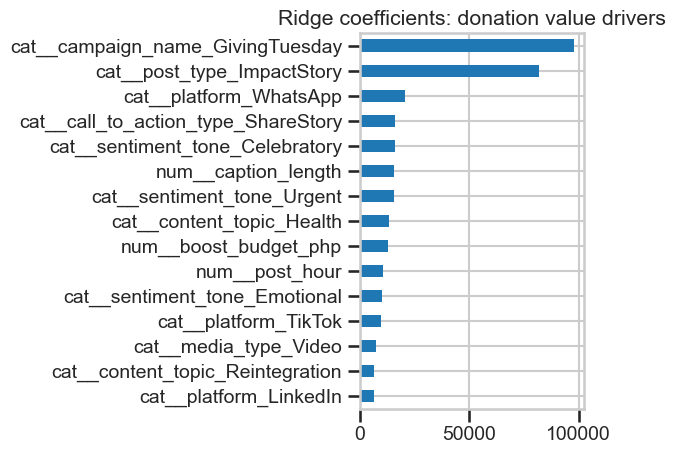

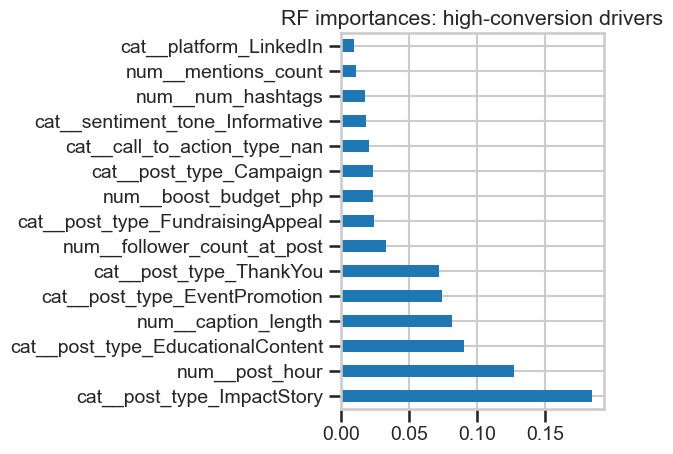

In [7]:
# Regression track: estimated donation value
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name, model in [
    ("baseline", DummyRegressor(strategy="mean")),
    ("ridge", Ridge(2.0)),
    ("rf", RandomForestRegressor(n_estimators=250, max_depth=8, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1)),
]:
    sc = cross_validate(reg_pipe(model), X, y_value, cv=kf, scoring={"mae": "neg_mean_absolute_error", "r2": "r2"}, n_jobs=-1)
    print("VALUE", name, "MAE", -sc["test_mae"].mean(), "R2", sc["test_r2"].mean())

# Classification track: high conversion post
for name, model in [
    ("baseline", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)),
    ("logit", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)),
    ("rf", RandomForestClassifier(n_estimators=250, max_depth=8, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1)),
]:
    sc = cross_validate(clf_pipe(model), X, y_high, cv=kf, scoring=["roc_auc", "f1"], n_jobs=-1)
    print("HIGH_CONV", name, "AUC", sc["test_roc_auc"].mean(), "F1", sc["test_f1"].mean())

# Holdout examples for business-friendly metrics
X_tr, X_te, yv_tr, yv_te = train_test_split(X, y_value, test_size=0.25, random_state=RANDOM_STATE)
rf_value = reg_pipe(RandomForestRegressor(n_estimators=250, max_depth=8, min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1))
rf_value.fit(X_tr, yv_tr)
yv_pred = rf_value.predict(X_te)
print("Holdout value MAE", mean_absolute_error(yv_te, yv_pred), "R2", r2_score(yv_te, yv_pred))

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X, y_high, test_size=0.25, random_state=RANDOM_STATE, stratify=y_high)
logit = clf_pipe(LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE))
logit.fit(Xc_tr, yc_tr)
pc = logit.predict_proba(Xc_te)[:, 1]
print("Holdout high-conv AUC", roc_auc_score(yc_te, pc))
print(classification_report(yc_te, (pc >= 0.5).astype(int), zero_division=0))

# Explainability artifacts
ridge = reg_pipe(Ridge(2.0)); ridge.fit(X, y_value)
coef = pd.Series(ridge.named_steps["model"].coef_, index=ridge.named_steps["prep"].get_feature_names_out()).sort_values()
coef.tail(15).plot(kind="barh", title="Ridge coefficients: donation value drivers")
plt.tight_layout(); plt.show()

rfc = clf_pipe(RandomForestClassifier(n_estimators=250, max_depth=8, class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1))
rfc.fit(X, y_high)
imp = pd.Series(rfc.named_steps["model"].feature_importances_, index=rfc.named_steps["prep"].get_feature_names_out()).sort_values(ascending=False).head(15)
imp.plot(kind="barh", title="RF importances: high-conversion drivers")
plt.tight_layout(); plt.show()


## 5. Evaluation & Interpretation

### Metrics
We report metrics appropriate to the task (regression: MAE, RMSE, R²; classification: accuracy, precision, recall, F1, ROC-AUC where applicable). **Grouped or held-out units** (donor, resident, safehouse) avoid optimistic scores when the same entity appears many times.

### What to look for
- **Lift over baseline:** if the interpretable and performance models barely beat the baseline, treat outputs as **weak decision support** until more data arrives.
- **Stability:** cross-validation spread indicates whether the model generalizes or chases noise.

---


## Business Interpretation

### What this means in plain English
Pipeline 10 now answers: **which posts are likely to drive donations**, and which content factors correlate with donation outcomes-not just engagement volume.

### How reliable is this for real decisions?
Useful for ranking and experimentation; treat absolute predictions as uncertain due to platform drift and campaign confounding.

### What should the organization do differently?
Prioritize high-scoring draft posts for paid spend and prime publishing slots; run A/B tests on top explanatory drivers each month.

### What decision does this directly support?
Weekly editorial and fundraising standup: pick which posts to boost and which creative templates to repeat.

### When the model is wrong
- **False positives (predicted high risk / high amount / etc., but reality was “fine”):**  
  A post predicted to convert may underperform, wasting budget or prime slot.
- **False negatives (model said “low concern” but something important happened):**  
  A post predicted low may actually convert, causing missed donation opportunity; keep an exploration quota for novel content.

---


## 6. Causal & Relationship Analysis

### What relationships showed up in the data
Engagement metrics often correlate with referrals/value, and platform/content combinations show measurable associations with donation outcomes.

### Why these are not proven causal
Boosting, algorithmic distribution, and campaign context confound direct causal claims.

### Honest limitations
Without randomized experiments or robust quasi-experimental design, findings remain correlational.

---


## Key Findings

- Donation-linked targets should lead content strategy, with engagement as a supporting diagnostic.
- Interpretable and performance models provide complementary value (guidance vs ranking).
- Strongest next improvement is time-split validation and controlled experiments.

---


## Recommended Actions

- Set monthly creative experiments around top drivers (CTA type, post type, timing).
- Allocate a fixed exploration budget to avoid overfitting to historical winners.
- Retrain quarterly and after major platform algorithm changes.

---


## 7. Deployment Plan

### What triggers scoring
Weekly batch scoring for upcoming post queue + nightly backfill after outcomes arrive.

### Where results appear in the .NET application
.NET Marketing module: post planner list shows `p_high_conversion`, `predicted_donation_value_php`, and top drivers.

### Who uses the output and how
| **Digital comms** | Calendar and creative choices |
| **Fundraising manager** | Budget and campaign decisions |

### PostgreSQL table schema

```sql
CREATE TABLE social_donation_impact_predictions (
  prediction_id BIGSERIAL PRIMARY KEY,
  post_id INTEGER,
  scored_for_date DATE NOT NULL,
  p_high_conversion DOUBLE PRECISION NOT NULL,
  predicted_donation_value_php DOUBLE PRECISION NOT NULL,
  model_version VARCHAR(40) NOT NULL,
  top_drivers JSONB,
  scored_at TIMESTAMPTZ NOT NULL DEFAULT NOW(),
  UNIQUE (post_id, scored_for_date, model_version)
);
```

### Example upsert (batch job after training/scoring)

```sql
INSERT INTO social_donation_impact_predictions
  (post_id, scored_for_date, p_high_conversion, predicted_donation_value_php, model_version, top_drivers)
VALUES
  (318, DATE '2026-04-07', 0.67, 12450.0, 'social_donation_v3', '[{"feature":"call_to_action_type","effect":"positive"}]'::jsonb)
ON CONFLICT (post_id, scored_for_date, model_version)
DO UPDATE SET
  p_high_conversion = EXCLUDED.p_high_conversion,
  predicted_donation_value_php = EXCLUDED.predicted_donation_value_php,
  top_drivers = EXCLUDED.top_drivers,
  scored_at = NOW();
```

### Python → PostgreSQL → .NET data flow
1. Scheduled **batch job** (e.g., nightly Airflow / Azure Function / Windows Task Scheduler) runs this notebook’s scoring script or a `joblib` loader.
2. Script reads the latest warehouse export or DB replica, builds features **as of `run_date`**, computes predictions.
3. Results are **UPSERTed** into the table below (idempotent per natural key).
4. The **.NET** admin API reads via EF Core or Dapper; UI shows sortable lists, filters, and **no raw model internals** to end users unless “explain” panel is explicitly designed.

Scoring job writes one record per draft/scheduled post; after posting, outcomes update a separate fact table used for retraining.

---


In [8]:
from joblib import dump
bundle = {
    "value_model": rf_value,
    "high_conversion_model": rfc,
    "feature_num": feature_num,
    "feature_cat": feature_cat,
    "referral_threshold": float(ref_thresh),
}
dump(bundle, OUTPUT_DIR / "social_donation_impact_v3.joblib")
print("Saved", OUTPUT_DIR / "social_donation_impact_v3.joblib")


Saved /Users/jaxon/Documents/BYU Archive/Winter 2026 - Junior Core IS/INTEX II/INTEX II EDA/ml_pipelines/artifacts/social_donation_impact_v3.joblib
